In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder,MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [24]:
data = pd.read_csv('tugas3_ganjil.csv')

In [25]:
categorical_cols = data.select_dtypes(include=['object']).columns
categorical_cols.tolist()

['Time',
 'Day_of_week',
 'Age_band_of_driver',
 'Sex_of_driver',
 'Educational_level',
 'Vehicle_driver_relation',
 'Driving_experience',
 'Type_of_vehicle',
 'Owner_of_vehicle',
 'Service_year_of_vehicle',
 'Defect_of_vehicle',
 'Area_accident_occured',
 'Lanes_or_Medians',
 'Road_allignment',
 'Types_of_Junction',
 'Road_surface_type',
 'Road_surface_conditions',
 'Light_conditions',
 'Weather_conditions',
 'Type_of_collision',
 'Vehicle_movement',
 'Casualty_class',
 'Sex_of_casualty',
 'Age_band_of_casualty',
 'Casualty_severity',
 'Work_of_casuality',
 'Fitness_of_casuality',
 'Pedestrian_movement',
 'Cause_of_accident',
 'Accident_severity']

In [26]:
label_encoder = LabelEncoder()
data['Sex_of_driver_encoded'] = label_encoder.fit_transform(data['Sex_of_driver'])

In [27]:
onehot_encoder = OneHotEncoder(sparse_output=False, drop='first')
owner_vehicle_encoded = onehot_encoder.fit_transform(data[['Owner_of_vehicle']])
owner_vehicle_df = pd.DataFrame(owner_vehicle_encoded, 
                                columns=onehot_encoder.get_feature_names_out(['Owner_of_vehicle']))
data = pd.concat([data, owner_vehicle_df], axis=1)

In [28]:
severity_order = ['Slight Injury', 'Serious Injury', 'Fatal injury']
ordinal_encoder = OrdinalEncoder(categories=[severity_order])
data['Accident_severity_encoded'] = ordinal_encoder.fit_transform(data[['Accident_severity']])

In [29]:
def time_to_seconds(t):
    h, m, s = map(int, t.split(':'))
    return h * 3600 + m * 60 + s
data['Time_seconds'] = data['Time'].apply(time_to_seconds)

In [30]:
print("\nSampel Waktu dan Detik:")
sample_times = data[['Time', 'Time_seconds']].head()
print(sample_times)


Sampel Waktu dan Detik:
       Time  Time_seconds
0  17:02:00         61320
1  17:02:00         61320
2  17:02:00         61320
3   1:06:00          3960
4   1:06:00          3960


In [31]:
test_time = "18:00:00"
test_seconds = time_to_seconds(test_time)
print(f"\nWaktu {test_time} = {test_seconds} detik")


Waktu 18:00:00 = 64800 detik


In [32]:
# Kelompok 1: 00:00 - 17:59
mask1 = (data['Time_seconds'] >= 0) & (data['Time_seconds'] <= 64799)
bins1 = [0, 10799, 36000, 50400, 64799]  # 00:00-02:59, 03:00-10:00, 11:00-14:00, 14:01-17:59
labels1 = ['Malam', 'Pagi', 'Siang', 'Sore']
data.loc[mask1, 'Time_binned'] = pd.cut(data.loc[mask1, 'Time_seconds'], 
                                        bins=bins1, 
                                        labels=labels1, 
                                        include_lowest=True)

# Debugging: Periksa kategori untuk 18:00:00
if test_seconds <= 64799:
    test_category = pd.cut([test_seconds], bins=bins1, labels=labels1, include_lowest=True)[0]
    print(f"Kategori untuk {test_time} (Kelompok 1): {test_category}")
else:
    print(f"{test_time} tidak masuk ke Kelompok 1 (00:00-17:59)")

# Kelompok 2: 18:00 - 23:59
mask2 = (data['Time_seconds'] >= 64800) & (data['Time_seconds'] <= 86399)
data.loc[mask2, 'Time_binned'] = 'Malam'

# Debugging: Periksa jika 18:00:00 masuk ke Kelompok 2
if test_seconds >= 64800 and test_seconds <= 86399:
    print(f"Kategori untuk {test_time} (Kelompok 2): Malam")
else:
    print(f"{test_time} tidak masuk ke Kelompok 2 (18:00-23:59)")

18:00:00 tidak masuk ke Kelompok 1 (00:00-17:59)
Kategori untuk 18:00:00 (Kelompok 2): Malam


In [33]:
data['Time_binned'] = pd.Categorical(data['Time_binned'], categories=['Malam', 'Pagi', 'Siang', 'Sore'], ordered=True)

print("\nDistribusi Time_binned:")
print(data['Time_binned'].value_counts().sort_index())


Distribusi Time_binned:
Time_binned
Malam    3704
Pagi     2417
Siang    2589
Sore     3606
Name: count, dtype: int64


In [34]:
minmax_scaler = MinMaxScaler()
data['Number_of_vehicles_scaled'] = minmax_scaler.fit_transform(data[['Number_of_vehicles_involved']])

In [35]:
zscore_scaler = StandardScaler()
data['Number_of_casualties_scaled'] = zscore_scaler.fit_transform(data[['Number_of_casualties']])

In [36]:
j = len(str(int(data['Number_of_casualties'].max())))
data['Number_of_casualties_decimal_scaled'] = data['Number_of_casualties'] / (10 ** j)
print("Max Number_of_casualties:", data['Number_of_casualties'].max())
print("j (jumlah digit):", j)
print("Sample Number_of_casualties_decimal_scaled:")
print(data['Number_of_casualties_decimal_scaled'].head())

Max Number_of_casualties: 8
j (jumlah digit): 1
Sample Number_of_casualties_decimal_scaled:
0    0.2
1    0.2
2    0.2
3    0.2
4    0.2
Name: Number_of_casualties_decimal_scaled, dtype: float64


In [37]:
j_time = len(str(int(data['Time_seconds'].max())))
data['Time_scaled'] = data['Time_seconds'] / (10 ** j_time)

In [38]:
numeric_data = data.select_dtypes(include=[np.number])
X = numeric_data.drop(['Number_of_casualties', 'Number_of_casualties_scaled', 'Number_of_casualties_decimal_scaled'], axis=1)
y = numeric_data['Number_of_casualties']

selector = SelectKBest(score_func=mutual_info_regression, k=4)
selector.fit(X, y)
scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
selected_features = X.columns[selector.get_support()].tolist()
print("Feature Selection Scores (Mutual Information):\n", scores.sort_values('Score', ascending=False))
print("Selected Features (Top 4):", selected_features)

Feature Selection Scores (Mutual Information):
                          Feature     Score
6                   Time_seconds  0.267579
8                    Time_scaled  0.262889
7      Number_of_vehicles_scaled  0.045476
0    Number_of_vehicles_involved  0.037414
4         Owner_of_vehicle_Owner  0.010175
3         Owner_of_vehicle_Other  0.005356
2  Owner_of_vehicle_Organization  0.002897
1          Sex_of_driver_encoded  0.000000
5      Accident_severity_encoded  0.000000
Selected Features (Top 4): ['Number_of_vehicles_involved', 'Time_seconds', 'Number_of_vehicles_scaled', 'Time_scaled']


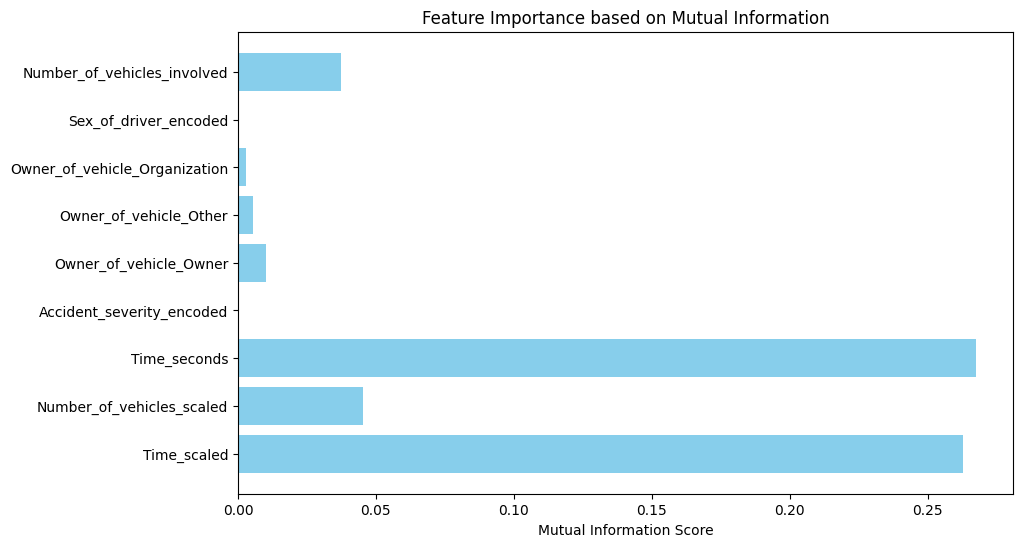

In [39]:
plt.figure(figsize=(10, 6))
plt.barh(scores['Feature'], scores['Score'], color='skyblue')
plt.xlabel('Mutual Information Score')
plt.title('Feature Importance based on Mutual Information')
plt.gca().invert_yaxis() 
plt.show()

In [40]:
scaler = StandardScaler()
pca_data = numeric_data.dropna()
pca_data_scaled = scaler.fit_transform(pca_data)
pca = PCA(n_components=5)
pca_result = pca.fit_transform(pca_data_scaled)

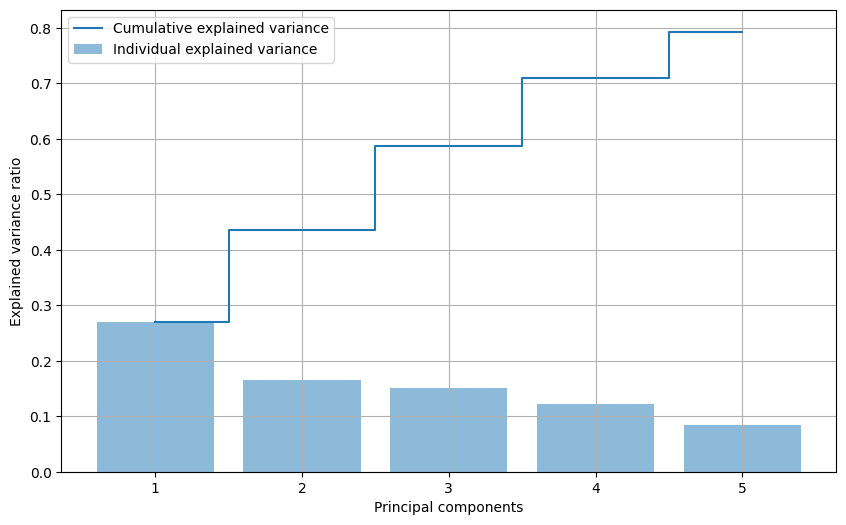

In [41]:
var_exp = pca.explained_variance_ratio_  # Individual explained variance
cum_var_exp = np.cumsum(pca.explained_variance_ratio_)  # Cumulative explained variance

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(cum_var_exp)+1), var_exp, alpha=0.5, align="center", label="Individual explained variance")
plt.step(range(1, len(cum_var_exp)+1), cum_var_exp, where="mid", label="Cumulative explained variance")
plt.ylabel("Explained variance ratio")
plt.xlabel("Principal components")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [42]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", sum(pca.explained_variance_ratio_))


Explained Variance Ratio: [0.27006032 0.16550416 0.15140501 0.12229862 0.08398449]
Total Explained Variance: 0.7932526012764631


In [43]:
train_df, temp_df = train_test_split(data, test_size=0.3, stratify=data['Accident_severity'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['Accident_severity'], random_state=42)

In [44]:
print("Train set shape:", train_df.shape)
print("Validation set shape:", val_df.shape)
print("Test set shape:", test_df.shape)
print("Severity distribution in Train:\n", train_df['Accident_severity'].value_counts(normalize=True))
print("Severity distribution in Validation:\n", val_df['Accident_severity'].value_counts(normalize=True))
print("Severity distribution in Test:\n", test_df['Accident_severity'].value_counts(normalize=True))


Train set shape: (8621, 43)
Validation set shape: (1847, 43)
Test set shape: (1848, 43)
Severity distribution in Train:
 Accident_severity
Slight Injury     0.845610
Serious Injury    0.141515
Fatal injury      0.012876
Name: proportion, dtype: float64
Severity distribution in Validation:
 Accident_severity
Slight Injury     0.845696
Serious Injury    0.141310
Fatal injury      0.012994
Name: proportion, dtype: float64
Severity distribution in Test:
 Accident_severity
Slight Injury     0.845779
Serious Injury    0.141775
Fatal injury      0.012446
Name: proportion, dtype: float64


In [46]:
data.to_csv('preprocessed_accident_data.csv', index=False)
train_df.to_csv('train_data.csv', index=False)
val_df.to_csv('val_data.csv', index=False)
test_df.to_csv('test_data.csv', index=False)
print("Data saved to CSV files.")

Data saved to CSV files.
